<a href="https://colab.research.google.com/github/Sanjaiguru06/ML-Practice-Experiments/blob/main/Experiment_8%20CART.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.8487394957983193

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.75      0.82       107
           1       0.82      0.93      0.87       131

    accuracy                           0.85       238
   macro avg       0.86      0.84      0.84       238
weighted avg       0.85      0.85      0.85       238


Confusion Matrix:
 [[ 80  27]
 [  9 122]]


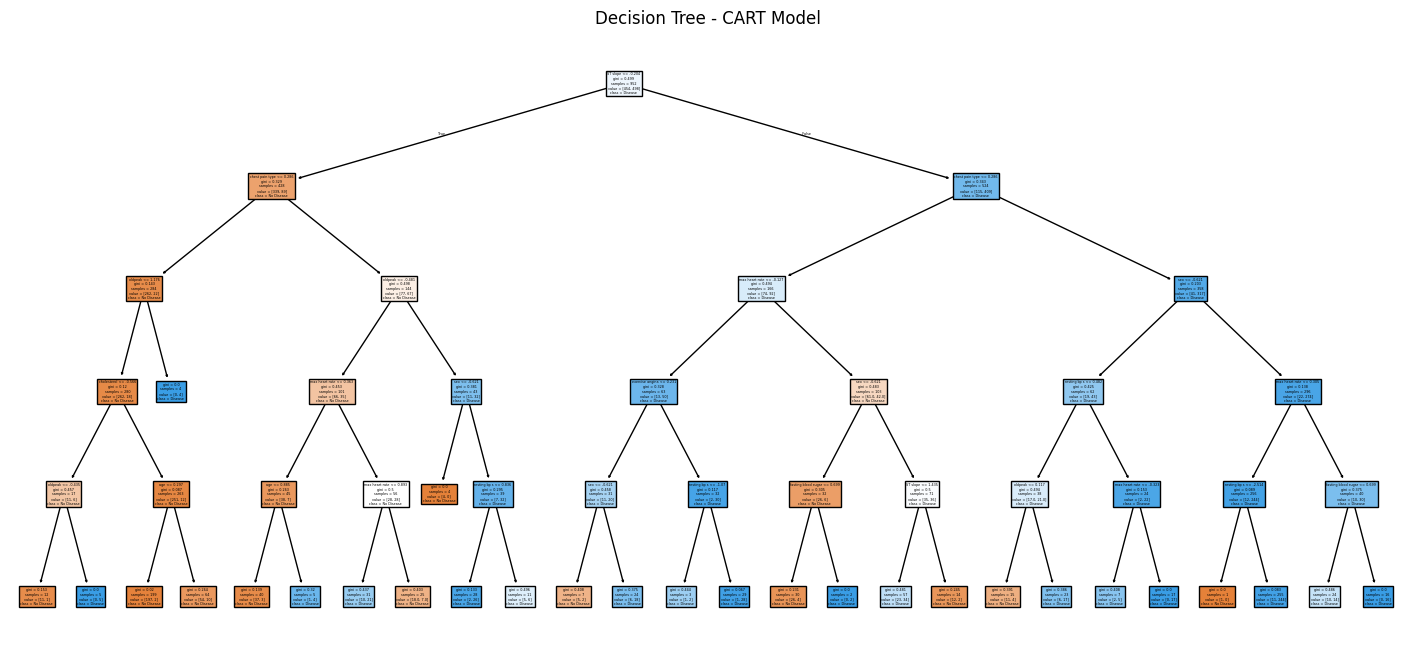

CART completed successfully. Output saved as 'CART_output.csv'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/sample_data/dataset.csv")
X = df.drop(columns=["target"])
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(18,8))
plot_tree(model, feature_names=df.drop(columns=["target"]).columns, class_names=["No Disease","Disease"], filled=True)
plt.title("Decision Tree - CART Model")
plt.show()

df["CART_Prediction"] = model.predict(X_scaled)
df.to_csv("CART_output.csv", index=False)
print("CART completed successfully. Output saved as 'CART_output.csv'")
